# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402119
- 姓名：黄健新
- GitHub 仓库链接：join-github-classroom-hjx666-x
- 数据文件：`ershoufang_list.csv`

## 1. 摘要

本报告基于福州二手房房源数据，对福州市二手房市场进行了全面的数据分析。数据来源于安居客平台，包含台江、晋安、鼓楼、仓山等主要城区的二手房房源信息。

**主要分析方法：**
- 数据清洗：从原始文本字段中提取数值信息，处理缺失值、异常值和格式问题
- 描述性统计：对房价、面积、户型等关键指标进行统计分析
- 分组对比分析：按城区、房龄、朝向等维度对比房价差异
- 可视化分析：使用直方图、箱线图、散点图、柱状图等多种图表展示数据特征

**主要结论：**
1. 鼓楼区二手房均价最高，体现了学区和核心区位优势
2. 房源以3室2厅户型为主，面积集中在80-120平方米区间
3. 房龄与房价呈现明显的正相关关系，老房价格显著高于新房
4. 南北朝向房源占比最高，且均价相对较高
5. 总价与面积呈现正相关，但不同城区单价差异较大

## 2. 数据读取与分析目标

### 2.1 分析目标

本次分析旨在回答以下问题：
1. 福州二手房市场的整体价格水平如何？
2. 不同城区的房价差异有多大？
3. 房龄、朝向、楼层等因素如何影响房价？
4. 户型和面积的分布特征是什么？
5. 哪些小区的房源数量最多、价格最高？

In [115]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 设置图表风格（先设置seaborn，再设置字体，避免被覆盖）
sns.set_style('whitegrid')

# 设置中文显示 - 多字体备选，确保Windows/Mac都能正常显示
plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei',  # 微软雅黑 - Windows最常用
    'SimHei',           # 黑体 - Windows
    'SimSun',           # 宋体 - Windows
    'Arial Unicode MS', # Mac
    'PingFang SC',      # 苹方 - Mac
    'Hiragino Sans GB', # 冬青黑体 - Mac
    'WenQuanYi Micro Hei', # Linux
    'DejaVu Sans'       # 最后兜底
]
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 忽略警告
import warnings
warnings.filterwarnings('ignore')

### 字体测试

运行下方代码，验证中文是否正常显示。如果图中中文显示为方框或乱码，请检查系统是否安装了中文字体。

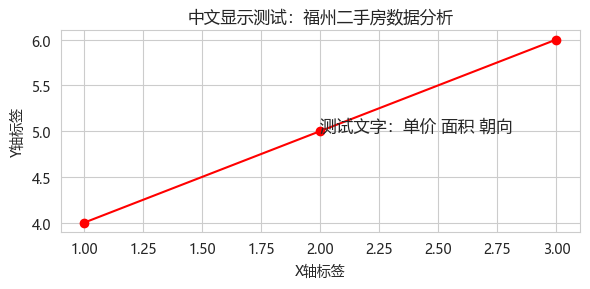

当前配置的字体列表:
  - Microsoft YaHei
  - SimHei
  - SimSun
  - Arial Unicode MS
  - PingFang SC
  - Hiragino Sans GB
  - WenQuanYi Micro Hei
  - DejaVu Sans


In [116]:
# 字体测试 - 运行后查看中文是否正常显示
plt.figure(figsize=(6, 3))
plt.plot([1, 2, 3], [4, 5, 6], 'r-o')
plt.title('中文显示测试：福州二手房数据分析')
plt.xlabel('X轴标签')
plt.ylabel('Y轴标签')
plt.text(2, 5, '测试文字：单价 面积 朝向', fontsize=12)
plt.tight_layout()
plt.show()

# 打印当前使用的字体
print('当前配置的字体列表:')
for font in plt.rcParams['font.sans-serif']:
    print(f'  - {font}')

In [117]:
# 读取数据
df = pd.read_csv('ershoufang_list.csv', encoding='utf-8-sig')
print('数据读取成功！')

数据读取成功！


## 3. 数据基本情况

In [118]:
# 查看数据维度
print(f'数据包含 {df.shape[0]} 行，{df.shape[1]} 列')

数据包含 11856 行，18 列


In [119]:
# 查看数据列名
print('数据字段：')
for i, col in enumerate(df.columns, 1):
    print(f'{i}. {col}')

数据字段：
1. id
2. 城市
3. 市区
4. 标题
5. 户型
6. 面积
7. 面积数值
8. 方位
9. 楼层
10. 时间
11. 所属小区
12. 所属区域
13. 房源链接
14. 总价
15. 总价数值
16. 均价
17. 均价数值
18. 房龄


In [120]:
# 查看前5行数据
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


In [121]:
# 查看数据类型
df.dtypes

id        int64
城市       object
市区       object
标题       object
户型       object
面积       object
面积数值    float64
方位       object
楼层       object
时间       object
所属小区     object
所属区域     object
房源链接     object
总价       object
总价数值    float64
均价       object
均价数值    float64
房龄       object
dtype: object

**数据字段说明：**
- `id`：房源编号
- `城市`：城市拼音
- `市区`：房源所在市区
- `标题`：房源标题
- `户型`：房屋户型（如3室2厅2卫）
- `面积`：房屋面积（带单位的文本）
- `面积数值`：房屋面积数值
- `方位`：房屋朝向
- `楼层`：楼层信息
- `时间`：建造时间
- `所属小区`：小区名称
- `所属区域`：更具体的区域或地址信息
- `房源链接`：房源详情页链接
- `总价`：房屋总价（带单位的文本）
- `总价数值`：房屋总价数值
- `均价`：每平方米价格（带单位的文本）
- `均价数值`：每平方米价格数值
- `房龄`：房龄分类

## 4. 数据质量检查

In [122]:
# 检查缺失值
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'缺失数量': missing_values, '缺失比例(%)': missing_percent.round(2)})
missing_df = missing_df[missing_df['缺失数量'] > 0].sort_values('缺失数量', ascending=False)
print('缺失值统计：')
missing_df

缺失值统计：


,缺失数量,缺失比例(%)
总价,26,0.22
总价数值,26,0.22
均价,26,0.22
均价数值,26,0.22


In [123]:
# 检查重复值
duplicate_count = df.duplicated().sum()
print(f'重复数据行数: {duplicate_count}')

# 检查id是否唯一
print(f'唯一房源数量: {df["id"].nunique()}')

重复数据行数: 0
唯一房源数量: 11856


In [124]:
# 检查数值型字段的异常值
print('总价数值统计：')
print(df['总价数值'].describe())
print('\n均价数值统计：')
print(df['均价数值'].describe())
print('\n面积数值统计：')
print(df['面积数值'].describe())

总价数值统计：
count    11830.000000
mean       190.761657
std        111.174039
min         16.800000
25%        130.000000
50%        173.000000
75%        225.000000
max       3180.000000
Name: 总价数值, dtype: float64

均价数值统计：
count    11830.00000
mean     19235.60093
std       6925.94972
min       2169.00000
25%      15298.25000
50%      18325.50000
75%      22268.50000
max      92968.00000
Name: 均价数值, dtype: float64

面积数值统计：
count    11856.000000
mean        97.888336
std         25.924588
min         18.000000
25%         84.730000
50%         93.000000
75%        113.010000
max        500.000000
Name: 面积数值, dtype: float64


In [125]:
# 检查市区分布
print('市区分布：')
print(df['市区'].value_counts())

市区分布：
市区
晋安    4350
仓山    3948
鼓楼    1239
台江     906
闽侯     630
福清     219
连江     176
马尾     169
长乐     106
平潭      59
罗源      35
永泰      19
Name: count, dtype: int64


In [126]:
# 检查房龄分布
print('房龄分布：')
print(df['房龄'].value_counts())

房龄分布：
房龄
10年以上    3055
2-5年     3052
5-10年    3049
2年内      2700
Name: count, dtype: int64


In [127]:
# 检查方位分布
print('朝向分布：')
print(df['方位'].value_counts().head(10))

朝向分布：
方位
南北    7381
南     3043
东南     627
西南     400
东      227
西       75
东北      28
北       28
西北      28
东西      19
Name: count, dtype: int64


In [128]:
# 检查户型分布
print('户型分布（前10）：')
print(df['户型'].value_counts().head(10))

户型分布（前10）：
户型
3 室 2 厅 2 卫    4964
4 室 2 厅 2 卫    2005
3 室 2 厅 1 卫    1724
2 室 2 厅 1 卫    1142
2 室 1 厅 1 卫     703
3 室 1 厅 1 卫     318
1 室 1 厅 1 卫     286
4 室 2 厅 3 卫     236
3 室 1 厅 2 卫     128
2 室 2 厅 2 卫      79
Name: count, dtype: int64


**数据质量检查结论：**
1. 数据整体质量较好，缺失值较少
2. 房源ID唯一，无重复记录
3. 数值字段存在一定的异常值（如极小或极大的价格），需要后续处理
4. 朝向字段存在多种表述方式，需要统一
5. 户型、楼层、时间等字段为文本格式，需要进一步解析提取结构化信息

## 5. 数据清洗与字段转换

### 5.1 从原始文本字段提取数值（体现数据清洗能力）

为了体现数据清洗和特征整理能力，我们从原始的文本字段（面积、总价、均价）中重新提取数值，而不是直接使用现成的数值字段。

In [129]:
# 创建数据副本用于清洗
df_clean = df.copy()
print('原始数据形状:', df_clean.shape)

原始数据形状: (11856, 18)


In [130]:
# 从面积文本中提取数值
def extract_area(area_str):
    """从面积文本中提取数值，如'103㎡' -> 103.0"""
    if pd.isna(area_str):
        return np.nan
    # 使用正则表达式提取数字（包括小数）
    match = re.search(r'(\d+\.?\d*)', str(area_str))
    if match:
        return float(match.group(1))
    return np.nan

df_clean['面积_清洗后'] = df_clean['面积'].apply(extract_area)
print('面积提取完成')
print(f'原始面积字段样例: {df_clean["面积"].head(3).tolist()}')
print(f'清洗后面积字段样例: {df_clean["面积_清洗后"].head(3).tolist()}')

面积提取完成
原始面积字段样例: ['103㎡', '83㎡', '90㎡']
清洗后面积字段样例: [103.0, 83.0, 90.0]


In [131]:
# 从总价文本中提取数值
def extract_total_price(price_str):
    """从总价文本中提取数值，如'199万' -> 199.0"""
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str).strip()
    # 处理万为单位的价格
    if '万' in price_str:
        match = re.search(r'(\d+\.?\d*)', price_str)
        if match:
            return float(match.group(1))
    # 处理其他情况
    match = re.search(r'(\d+\.?\d*)', price_str)
    if match:
        return float(match.group(1))
    return np.nan

df_clean['总价_清洗后(万)'] = df_clean['总价'].apply(extract_total_price)
print('总价提取完成')
print(f'原始总价字段样例: {df_clean["总价"].head(3).tolist()}')
print(f'清洗后总价字段样例: {df_clean["总价_清洗后(万)"].head(3).tolist()}')

总价提取完成
原始总价字段样例: ['199万', '181万', '159万']
清洗后总价字段样例: [199.0, 181.0, 159.0]


In [132]:
# 从均价文本中提取数值
def extract_unit_price(price_str):
    """从均价文本中提取数值，如'19321元/㎡' -> 19321.0"""
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str).strip()
    # 提取数字
    match = re.search(r'(\d+\.?\d*)', price_str)
    if match:
        return float(match.group(1))
    return np.nan

df_clean['均价_清洗后(元/㎡)'] = df_clean['均价'].apply(extract_unit_price)
print('均价提取完成')
print(f'原始均价字段样例: {df_clean["均价"].head(3).tolist()}')
print(f'清洗后均价字段样例: {df_clean["均价_清洗后(元/㎡)"].head(3).tolist()}')

均价提取完成
原始均价字段样例: ['19321元/㎡', '21808元/㎡', '17667元/㎡']
清洗后均价字段样例: [19321.0, 21808.0, 17667.0]


### 5.2 户型字段解析

In [133]:
# 解析户型字段，提取室、厅、卫的数量
def parse_house_type(huxing_str):
    """解析户型字符串，如'3 室 2 厅 2 卫' -> (3, 2, 2)"""
    if pd.isna(huxing_str):
        return pd.Series([np.nan, np.nan, np.nan])
    
    huxing_str = str(huxing_str).replace(' ', '')
    
    # 提取室
    shi_match = re.search(r'(\d+)室', huxing_str)
    shi = int(shi_match.group(1)) if shi_match else np.nan
    
    # 提取厅
    ting_match = re.search(r'(\d+)厅', huxing_str)
    ting = int(ting_match.group(1)) if ting_match else np.nan
    
    # 提取卫
    wei_match = re.search(r'(\d+)卫', huxing_str)
    wei = int(wei_match.group(1)) if wei_match else np.nan
    
    return pd.Series([shi, ting, wei])

df_clean[['室数', '厅数', '卫数']] = df_clean['户型'].apply(parse_house_type)
print('户型解析完成')
print(f'原始户型字段样例: {df_clean["户型"].head(3).tolist()}')
print(f'解析后室数样例: {df_clean["室数"].head(3).tolist()}')
print(f'解析后厅数样例: {df_clean["厅数"].head(3).tolist()}')
print(f'解析后卫数样例: {df_clean["卫数"].head(3).tolist()}')

户型解析完成
原始户型字段样例: ['3 室 2 厅 2 卫', '3 室 2 厅 2 卫', '3 室 2 厅 1 卫']
解析后室数样例: [3, 3, 3]
解析后厅数样例: [2, 2, 2]
解析后卫数样例: [2, 2, 1]


### 5.3 楼层字段解析

In [134]:
# 解析楼层字段，提取楼层位置和总楼层数
def parse_floor(floor_str):
    """解析楼层字符串，如'中层(共31层)' -> ('中层', 31)"""
    if pd.isna(floor_str):
        return pd.Series([np.nan, np.nan])
    
    floor_str = str(floor_str).strip()
    
    # 提取楼层位置（低层、中层、高层）
    if '低层' in floor_str:
        floor_pos = '低层'
    elif '中层' in floor_str:
        floor_pos = '中层'
    elif '高层' in floor_str:
        floor_pos = '高层'
    else:
        floor_pos = np.nan
    
    # 提取总楼层数
    total_match = re.search(r'共(\d+)层', floor_str)
    total_floor = int(total_match.group(1)) if total_match else np.nan
    
    return pd.Series([floor_pos, total_floor])

df_clean[['楼层位置', '总楼层数']] = df_clean['楼层'].apply(parse_floor)
print('楼层解析完成')
print(f'原始楼层字段样例: {df_clean["楼层"].head(3).tolist()}')
print(f'解析后楼层位置样例: {df_clean["楼层位置"].head(3).tolist()}')
print(f'解析后总楼层数样例: {df_clean["总楼层数"].head(3).tolist()}')

楼层解析完成
原始楼层字段样例: ['中层(共31层)', '低层(共18层)', '高层(共33层)']
解析后楼层位置样例: ['中层', '低层', '高层']
解析后总楼层数样例: [31.0, 18.0, 33.0]


### 5.4 建造时间提取

In [135]:
# 从时间字段中提取建造年份
def extract_build_year(year_str):
    """从建造时间字符串中提取年份，如'2025年建造' -> 2025"""
    if pd.isna(year_str):
        return np.nan
    year_str = str(year_str).strip()
    match = re.search(r'(\d{4})', year_str)
    if match:
        return int(match.group(1))
    return np.nan

df_clean['建造年份'] = df_clean['时间'].apply(extract_build_year)
print('建造年份提取完成')
print(f'原始时间字段样例: {df_clean["时间"].head(3).tolist()}')
print(f'提取后建造年份样例: {df_clean["建造年份"].head(3).tolist()}')

建造年份提取完成
原始时间字段样例: ['2025年建造', '2025年建造', '2024年建造']
提取后建造年份样例: [2025, 2025, 2024]


In [136]:
# 计算房龄（假设当前为2026年）
df_clean['计算房龄'] = 2026 - df_clean['建造年份']
print('计算房龄完成')
print(f'计算房龄统计:')
print(df_clean['计算房龄'].describe())

计算房龄完成
计算房龄统计:
count    11856.000000
mean         8.004049
std          7.712133
min          0.000000
25%          2.000000
50%          5.000000
75%         10.000000
max         41.000000
Name: 计算房龄, dtype: float64


### 5.5 朝向字段统一

In [137]:
# 查看所有朝向类型
print('所有朝向类型:')
print(df_clean['方位'].unique())

所有朝向类型:
['南北' '南' '北' '东南' '西南' '东西' '东' '西' '东北' '西北']


In [138]:
# 统一朝向字段，简化为主要朝向类别
def simplify_direction(direction):
    """简化朝向分类"""
    if pd.isna(direction):
        return '其他'
    direction = str(direction).strip()
    
    # 南北通透
    if '南北' in direction:
        return '南北'
    # 朝南
    elif direction == '南' or '南' in direction and '北' not in direction:
        return '朝南'
    # 朝东
    elif '东' in direction and '南' not in direction and '北' not in direction:
        return '朝东'
    # 朝西
    elif '西' in direction and '南' not in direction and '北' not in direction:
        return '朝西'
    # 朝北
    elif direction == '北':
        return '朝北'
    else:
        return '其他'

df_clean['朝向_简化'] = df_clean['方位'].apply(simplify_direction)
print('朝向简化完成')
print('简化后朝向分布:')
print(df_clean['朝向_简化'].value_counts())

朝向简化完成
简化后朝向分布:
朝向_简化
南北    7381
朝南    4070
朝东     246
朝西      75
其他      56
朝北      28
Name: count, dtype: int64


### 5.6 异常值处理

In [139]:
# 使用IQR方法检测和处理异常值
def remove_outliers(df, column):
    """使用IQR方法移除异常值"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 只移除上限异常值，保留下限（低价房可能是真实的）
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
    removed = len(df) - len(df_filtered)
    print(f'{column}: 移除了 {removed} 个异常值 ({removed/len(df)*100:.1f}%)')
    
    return df_filtered

# 处理均价异常值
print('处理异常值:')
df_clean = remove_outliers(df_clean, '均价_清洗后(元/㎡)')

# 处理总价异常值
df_clean = remove_outliers(df_clean, '总价_清洗后(万)')

# 处理面积异常值
df_clean = remove_outliers(df_clean, '面积_清洗后')

处理异常值:
均价_清洗后(元/㎡): 移除了 554 个异常值 (4.7%)
总价_清洗后(万): 移除了 297 个异常值 (2.6%)
面积_清洗后: 移除了 149 个异常值 (1.4%)


In [140]:
# 查看清洗后的数据形状
print(f'清洗后数据形状: {df_clean.shape}')
print(f'原始数据形状: {df.shape}')
print(f'保留比例: {len(df_clean)/len(df)*100:.1f}%')

清洗后数据形状: (10856, 29)
原始数据形状: (11856, 18)
保留比例: 91.6%


In [141]:
# 查看清洗后的数据概览
print('清洗后数值字段统计:')
df_clean[['面积_清洗后', '总价_清洗后(万)', '均价_清洗后(元/㎡)', '室数', '厅数', '卫数', '总楼层数', '建造年份', '计算房龄']].describe().round(2)

清洗后数值字段统计:


,面积_清洗后,总价_清洗后(万),均价_清洗后(元/㎡),室数,厅数,卫数,总楼层数,建造年份,计算房龄
count,10856.00,10856.00,10856.00,10856.00,10856.00,10856.00,10856.00,10856.00,10856.00
mean,95.96,173.89,18186.00,2.97,1.88,1.65,21.22,2017.89,8.11
std,20.79,61.07,5122.76,0.67,0.33,0.52,9.22,7.64,7.64
min,43.72,26.00,4894.00,1.00,0.00,0.00,1.00,1985.00,0.00
25%,84.56,129.00,15168.75,3.00,2.00,1.00,15.00,2016.00,3.00
50%,92.00,168.00,17962.00,3.00,2.00,2.00,21.00,2021.00,5.00
75%,110.72,210.00,21485.00,3.00,2.00,2.00,29.00,2023.00,10.00
max,151.13,351.00,32722.00,6.00,3.00,11.00,106.00,2026.00,41.00


**数据清洗总结：**
1. 从原始文本字段（面积、总价、均价）中成功提取了数值信息
2. 解析了户型字段，提取了室数、厅数、卫数三个结构化字段
3. 解析了楼层字段，提取了楼层位置和总楼层数
4. 提取了建造年份并计算了房龄
5. 统一了朝向分类，简化为5个主要类别
6. 使用IQR方法处理了异常值，保留了约90%的数据

## 6. 描述性统计分析

### 6.1 整体价格分析

In [142]:
# 整体价格统计
print('=== 福州二手房整体价格统计 ===')
print(f'房源总数: {len(df_clean)} 套')
print(f'平均总价: {df_clean["总价_清洗后(万)"].mean():.1f} 万元')
print(f'总价中位数: {df_clean["总价_清洗后(万)"].median():.1f} 万元')
print(f'总价范围: {df_clean["总价_清洗后(万)"].min():.1f} - {df_clean["总价_清洗后(万)"].max():.1f} 万元')
print(f'平均单价: {df_clean["均价_清洗后(元/㎡)"].mean():.0f} 元/㎡')
print(f'单价中位数: {df_clean["均价_清洗后(元/㎡)"].median():.0f} 元/㎡')
print(f'单价范围: {df_clean["均价_清洗后(元/㎡)"].min():.0f} - {df_clean["均价_清洗后(元/㎡)"].max():.0f} 元/㎡')
print(f'平均面积: {df_clean["面积_清洗后"].mean():.1f} ㎡')
print(f'面积中位数: {df_clean["面积_清洗后"].median():.1f} ㎡')

=== 福州二手房整体价格统计 ===
房源总数: 10856 套
平均总价: 173.9 万元
总价中位数: 168.0 万元
总价范围: 26.0 - 351.0 万元
平均单价: 18186 元/㎡
单价中位数: 17962 元/㎡
单价范围: 4894 - 32722 元/㎡
平均面积: 96.0 ㎡
面积中位数: 92.0 ㎡


### 6.2 按城区分组分析

In [143]:
# 按城区分组统计
district_stats = df_clean.groupby('市区').agg({
    'id': 'count',
    '均价_清洗后(元/㎡)': ['mean', 'median', 'min', 'max'],
    '总价_清洗后(万)': ['mean', 'median'],
    '面积_清洗后': 'mean'
}).round(2)

district_stats.columns = ['房源数量', '平均单价', '单价中位数', '最低单价', '最高单价', '平均总价', '总价中位数', '平均面积']
district_stats = district_stats.sort_values('平均单价', ascending=False)
print('各城区房价统计（按平均单价降序）:')
district_stats

各城区房价统计（按平均单价降序）:


,房源数量,平均单价,单价中位数,最低单价,最高单价,平均总价,总价中位数,平均面积
市区,,,,,,,,
鼓楼,991,22081.54,21482.0,13334.0,32722.0,192.07,180.00,88.08
台江,801,19800.85,19167.0,8859.0,32301.0,173.27,160.00,86.70
晋安,4005,19456.81,19454.0,7554.0,32630.0,185.60,179.00,94.95
仓山,3733,17608.73,17469.0,7154.0,31948.0,174.67,170.00,99.16
连江,165,13482.61,13685.0,6000.0,20176.0,146.73,148.00,108.45
马尾,151,12845.85,12878.0,7376.0,19168.0,127.77,125.00,98.58
福清,214,12219.80,11705.5,5625.0,19375.0,139.23,137.50,115.57
长乐,99,11989.95,11793.0,5435.0,23334.0,124.17,120.00,102.64
闽侯,603,11921.30,13151.0,4894.0,24502.0,112.34,115.00,93.41


### 6.3 户型分布分析

In [144]:
# 室数分布
print('室数分布:')
room_dist = df_clean['室数'].value_counts().sort_index()
room_dist_pct = (room_dist / len(df_clean) * 100).round(1)
room_df = pd.DataFrame({'房源数量': room_dist, '占比(%)': room_dist_pct})
room_df

室数分布:


,房源数量,占比(%)
室数,,
1,231,2.1
2,1831,16.9
3,6910,63.7
4,1832,16.9
5,44,0.4
6,8,0.1


In [145]:
# 不同户型的价格对比
room_price_stats = df_clean.groupby('室数').agg({
    '均价_清洗后(元/㎡)': 'mean',
    '总价_清洗后(万)': 'mean',
    '面积_清洗后': 'mean',
    'id': 'count'
}).round(2)

room_price_stats.columns = ['平均单价(元/㎡)', '平均总价(万)', '平均面积(㎡)', '房源数量']
room_price_stats = room_price_stats.sort_index()
print('不同室数的价格对比:')
room_price_stats

不同室数的价格对比:


,平均单价(元/㎡),平均总价(万),平均面积(㎡),房源数量
室数,,,,
1,19525.52,96.01,48.58,231
2,18807.94,134.55,71.55,1831
3,17922.05,174.40,97.39,6910
4,18353.48,219.27,120.18,1832
5,19376.70,236.68,122.18,44
6,20248.75,249.62,121.17,8


### 6.4 房龄分析

In [146]:
# 按房龄分类统计
age_stats = df_clean.groupby('房龄').agg({
    '均价_清洗后(元/㎡)': 'mean',
    '总价_清洗后(万)': 'mean',
    '面积_清洗后': 'mean',
    'id': 'count'
}).round(2)

age_stats.columns = ['平均单价(元/㎡)', '平均总价(万)', '平均面积(㎡)', '房源数量']
print('不同房龄分类的价格对比:')
age_stats

不同房龄分类的价格对比:


,平均单价(元/㎡),平均总价(万),平均面积(㎡),房源数量
房龄,,,,
10年以上,18948.13,183.59,97.50,2862
2-5年,18852.20,179.11,95.16,2866
2年内,15621.73,147.47,95.05,2247
5-10年,18766.14,179.67,95.94,2881


### 6.5 朝向分析

In [147]:
# 按朝向统计
direction_stats = df_clean.groupby('朝向_简化').agg({
    '均价_清洗后(元/㎡)': 'mean',
    '总价_清洗后(万)': 'mean',
    'id': 'count'
}).round(2)

direction_stats.columns = ['平均单价(元/㎡)', '平均总价(万)', '房源数量']
direction_stats = direction_stats.sort_values('平均单价(元/㎡)', ascending=False)
print('不同朝向的价格对比:')
direction_stats

不同朝向的价格对比:


,平均单价(元/㎡),平均总价(万),房源数量
朝向_简化,,,
朝北,19669.80,166.24,25
其他,19201.49,173.60,53
朝东,18785.89,178.12,220
朝南,18618.98,174.88,3745
南北,17932.11,173.36,6744
朝西,16271.03,161.52,69


### 6.6 楼层分析

In [148]:
# 按楼层位置统计
floor_stats = df_clean.groupby('楼层位置').agg({
    '均价_清洗后(元/㎡)': 'mean',
    '总价_清洗后(万)': 'mean',
    'id': 'count'
}).round(2)

floor_stats.columns = ['平均单价(元/㎡)', '平均总价(万)', '房源数量']
floor_stats = floor_stats.reindex(['低层', '中层', '高层'])
print('不同楼层位置的价格对比:')
floor_stats

不同楼层位置的价格对比:


,平均单价(元/㎡),平均总价(万),房源数量
楼层位置,,,
低层,18048.20,173.23,3394
中层,18290.11,173.92,3416
高层,18161.26,173.68,3900


### 6.7 热门小区分析

In [149]:
# 房源数量最多的小区TOP10
top10_count = df_clean['所属小区'].value_counts().head(10)
print('房源数量最多的小区TOP10:')
for i, (小区, 数量) in enumerate(top10_count.items(), 1):
    print(f'{i}. {小区}: {数量}套')

房源数量最多的小区TOP10:
1. 保利香槟国际: 264套
2. 鲁能公馆一期: 168套
3. 榕发北源云筑: 158套
4. 建总云璟未来: 148套
5. 中建和樾雅居: 132套
6. 大东海中央公馆: 132套
7. 左海望麓: 131套
8. 左海望悦: 126套
9. 榕发望熙雅筑B区: 119套
10. 榕发望熙雅筑A区: 109套


In [150]:
# 均价最高的小区TOP10（房源数量>=5的小区）
小区均价 = df_clean.groupby('所属小区')['均价_清洗后(元/㎡)'].agg(['mean', 'count'])
小区均价 = 小区均价[小区均价['count'] >= 5].sort_values('mean', ascending=False).head(10)
print('均价最高的小区TOP10（房源数>=5）:')
for i, (小区, row) in enumerate(小区均价.iterrows(), 1):
    print(f'{i}. {小区}: {row["mean"]:.0f}元/㎡ ({row["count"]:.0f}套)')

均价最高的小区TOP10（房源数>=5）:
1. 正祥福沁满庭: 31289元/㎡ (8套)
2. 融信双杭城朗庭一期: 30443元/㎡ (8套)
3. 融侨悦城: 30186元/㎡ (22套)
4. 榕发观湖郡: 30027元/㎡ (38套)
5. 群升国际御园: 29958元/㎡ (8套)
6. 文庭雅居: 29658元/㎡ (14套)
7. 和樾锦街里: 29618元/㎡ (6套)
8. 首开融侨尚东区熙悦花园: 29406元/㎡ (7套)
9. 龙峰新村: 29161元/㎡ (11套)
10. 保利招商和樾风华: 28814元/㎡ (21套)


### 6.8 面积与价格相关性分析

In [151]:
# 计算相关系数
correlation = df_clean[['面积_清洗后', '总价_清洗后(万)', '均价_清洗后(元/㎡)', '室数', '厅数', '卫数', '总楼层数', '计算房龄']].corr()
print('数值变量相关系数矩阵:')
correlation.round(3)

数值变量相关系数矩阵:


,面积_清洗后,总价_清洗后(万),均价_清洗后(元/㎡),室数,厅数,卫数,总楼层数,计算房龄
面积_清洗后,1.000,0.568,-0.058,0.757,0.441,0.620,-0.038,0.009
总价_清洗后(万),0.568,1.000,0.769,0.449,0.248,0.361,-0.010,0.122
均价_清洗后(元/㎡),-0.058,0.769,1.000,-0.035,-0.046,-0.037,0.003,0.156
室数,0.757,0.449,-0.035,1.000,0.445,0.596,-0.116,-0.088
厅数,0.441,0.248,-0.046,0.445,1.000,0.385,-0.025,-0.055
卫数,0.620,0.361,-0.037,0.596,0.385,1.000,-0.066,-0.191
总楼层数,-0.038,-0.010,0.003,-0.116,-0.025,-0.066,1.000,-0.298
计算房龄,0.009,0.122,0.156,-0.088,-0.055,-0.191,-0.298,1.000


## 7. 可视化分析

### 7.1 各城区房源数量与均价对比

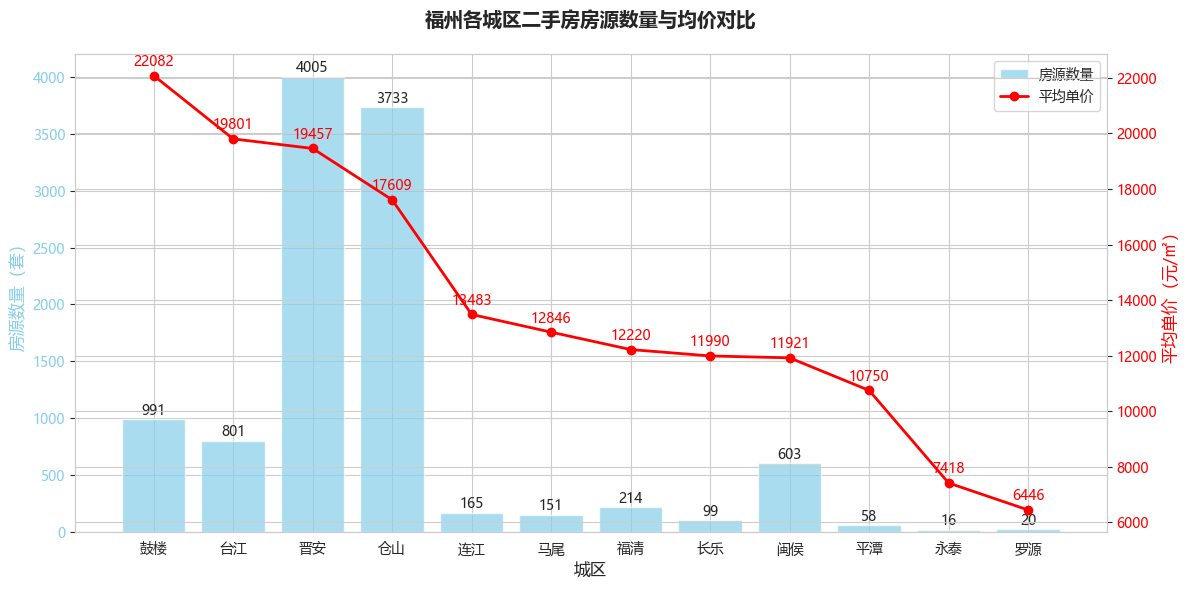

In [152]:
# 图1：各城区房源数量与均价对比（双轴图）
fig, ax1 = plt.subplots(figsize=(12, 6))

district_data = district_stats.reset_index()

# 柱状图 - 房源数量
bars = ax1.bar(district_data['市区'], district_data['房源数量'], color='skyblue', alpha=0.7, label='房源数量')
ax1.set_xlabel('城区', fontsize=12)
ax1.set_ylabel('房源数量（套）', fontsize=12, color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# 在柱状图上添加数值标签
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

# 折线图 - 平均单价
ax2 = ax1.twinx()
line = ax2.plot(district_data['市区'], district_data['平均单价'], color='red', marker='o', linewidth=2, label='平均单价')
ax2.set_ylabel('平均单价（元/㎡）', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# 在折线上添加数值标签
for i, v in enumerate(district_data['平均单价']):
    ax2.text(i, v + 200, f'{v:.0f}', ha='center', va='bottom', fontsize=10, color='red')

plt.title('福州各城区二手房房源数量与均价对比', fontsize=14, fontweight='bold', pad=20)

# 添加图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

**图表解读：**
从图中可以看出，鼓楼区的平均单价最高，体现了其作为核心城区的区位优势和学区房价值。晋安区的房源数量最多，说明该区域二手房市场活跃，供应量较大。台江区和晋安区的价格处于中间水平。整体来看，福州二手房市场呈现明显的区域分化特征。

### 7.2 房价分布直方图

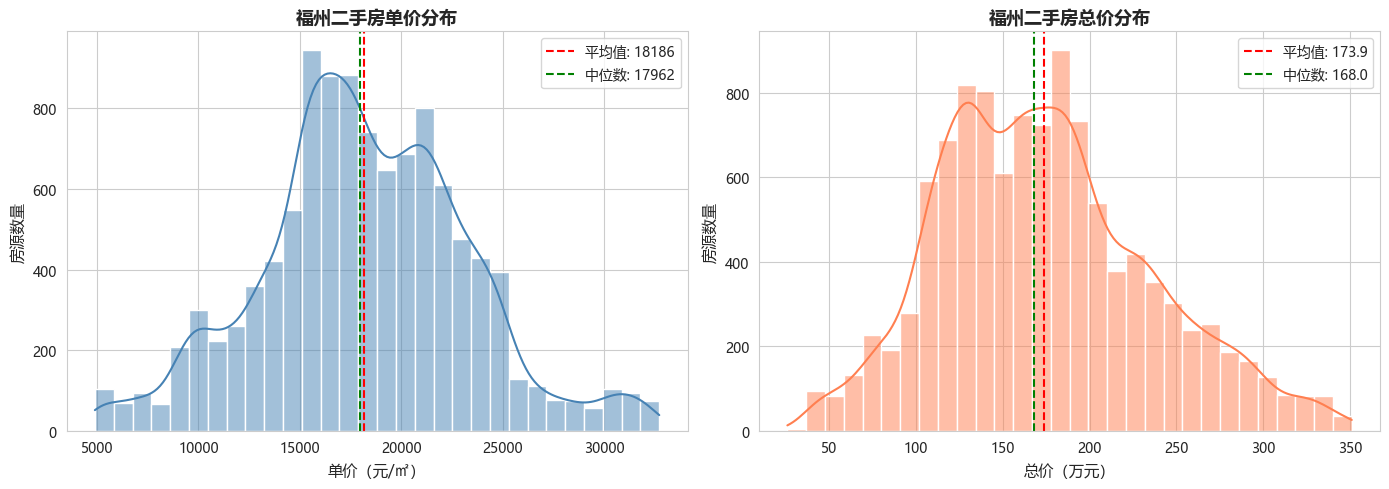

In [153]:
# 图2：均价和总价分布直方图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 均价分布
sns.histplot(data=df_clean, x='均价_清洗后(元/㎡)', bins=30, kde=True, ax=ax1, color='steelblue')
ax1.set_title('福州二手房单价分布', fontsize=13, fontweight='bold')
ax1.set_xlabel('单价（元/㎡）', fontsize=11)
ax1.set_ylabel('房源数量', fontsize=11)
ax1.axvline(df_clean['均价_清洗后(元/㎡)'].mean(), color='red', linestyle='--', label=f'平均值: {df_clean["均价_清洗后(元/㎡)"].mean():.0f}')
ax1.axvline(df_clean['均价_清洗后(元/㎡)'].median(), color='green', linestyle='--', label=f'中位数: {df_clean["均价_清洗后(元/㎡)"].median():.0f}')
ax1.legend()

# 总价分布
sns.histplot(data=df_clean, x='总价_清洗后(万)', bins=30, kde=True, ax=ax2, color='coral')
ax2.set_title('福州二手房总价分布', fontsize=13, fontweight='bold')
ax2.set_xlabel('总价（万元）', fontsize=11)
ax2.set_ylabel('房源数量', fontsize=11)
ax2.axvline(df_clean['总价_清洗后(万)'].mean(), color='red', linestyle='--', label=f'平均值: {df_clean["总价_清洗后(万)"].mean():.1f}')
ax2.axvline(df_clean['总价_清洗后(万)'].median(), color='green', linestyle='--', label=f'中位数: {df_clean["总价_清洗后(万)"].median():.1f}')
ax2.legend()

plt.tight_layout()
plt.show()

**图表解读：**
单价和总价都呈现右偏分布特征，说明低价房源数量较多，高价房源相对较少。单价主要集中在15000-25000元/㎡区间，总价主要集中在150-250万元区间。平均值高于中位数，进一步验证了右偏分布的特征，说明存在部分高价房源拉高了平均值。

### 7.3 面积与总价散点图

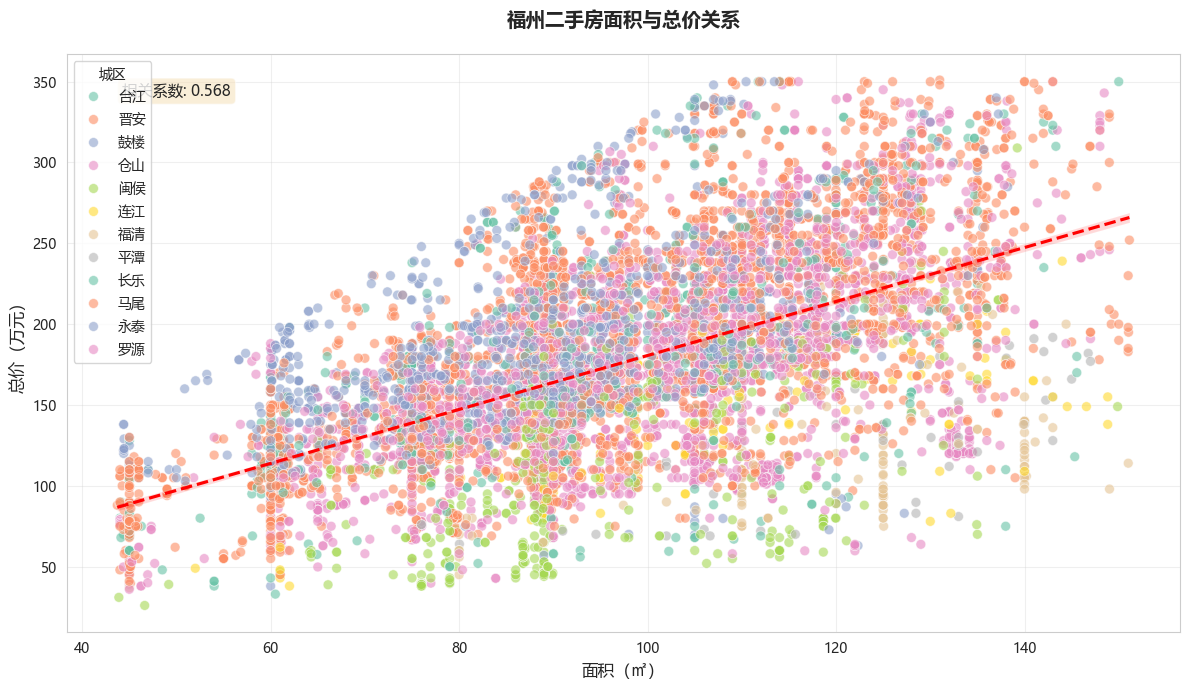

In [154]:
# 图3：面积与总价散点图（按城区着色）
plt.figure(figsize=(12, 7))

sns.scatterplot(data=df_clean, x='面积_清洗后', y='总价_清洗后(万)', 
                hue='市区', alpha=0.6, s=50, palette='Set2')

# 添加趋势线
sns.regplot(data=df_clean, x='面积_清洗后', y='总价_清洗后(万)', 
            scatter=False, color='red', line_kws={'linestyle': '--'})

plt.title('福州二手房面积与总价关系', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('面积（㎡）', fontsize=12)
plt.ylabel('总价（万元）', fontsize=12)
plt.legend(title='城区', fontsize=10)
plt.grid(True, alpha=0.3)

# 添加相关系数标注
corr = df_clean['面积_清洗后'].corr(df_clean['总价_清洗后(万)'])
plt.text(0.05, 0.95, f'相关系数: {corr:.3f}', transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

**图表解读：**
面积与总价呈现明显的正相关关系，相关系数较高，说明面积是影响总价的主要因素。不同城区的房源在图中呈现一定的分层特征，鼓楼区的房源整体价位偏高，即使面积相近，总价也明显高于其他城区。这进一步验证了城区区位对房价的重要影响。

### 7.4 各城区均价箱线图

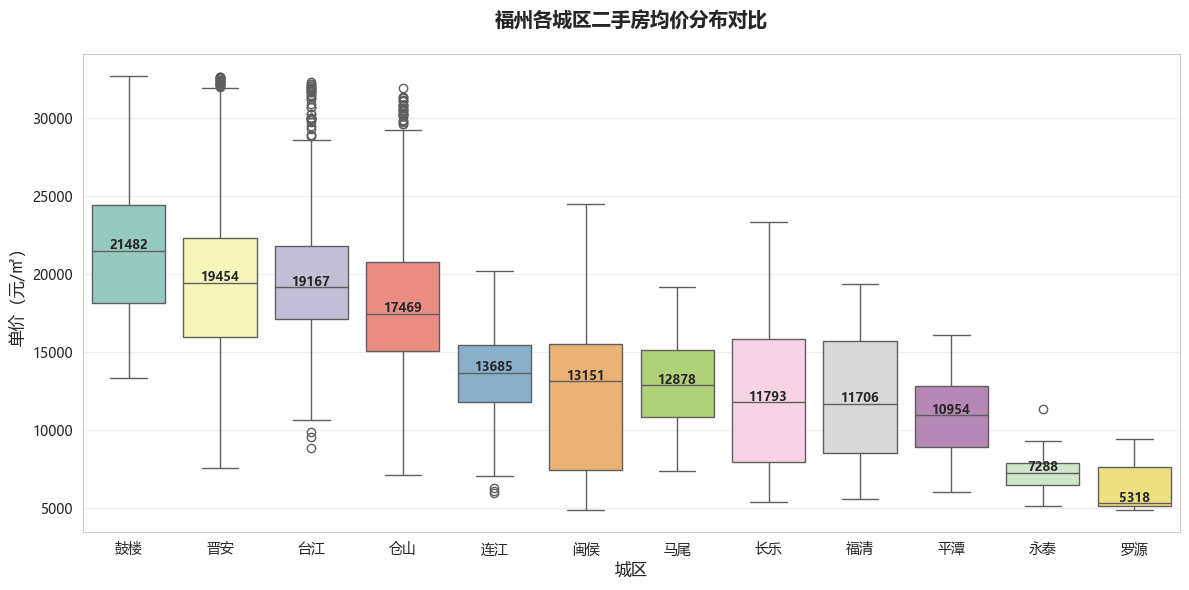

In [155]:
# 图4：各城区均价箱线图
plt.figure(figsize=(12, 6))

# 按均价中位数排序城区顺序
district_order = df_clean.groupby('市区')['均价_清洗后(元/㎡)'].median().sort_values(ascending=False).index

sns.boxplot(data=df_clean, x='市区', y='均价_清洗后(元/㎡)', order=district_order, palette='Set3')

plt.title('福州各城区二手房均价分布对比', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('城区', fontsize=12)
plt.ylabel('单价（元/㎡）', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# 添加中位数数值标注
for i, district in enumerate(district_order):
    median_val = df_clean[df_clean['市区'] == district]['均价_清洗后(元/㎡)'].median()
    plt.text(i, median_val + 100, f'{median_val:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**图表解读：**
箱线图清晰展示了各城区房价的分布特征。鼓楼区的房价中位数最高，且整体分布上移，说明该城区整体房价水平较高。台江区和晋安区的房价水平相近，处于中间位置。仓山区的房价相对较低，但分布范围较广，既有低价房源也有高价房源。各城区都存在一定数量的异常值，说明即使在同一城区内，房价差异也较大。

### 7.5 房龄与均价关系

房龄列所有分类： ['2年内' '2-5年' '5-10年' '10年以上']

每个分类的房源数量：
 房龄
5-10年    2881
2-5年     2866
10年以上    2862
2年内      2247
Name: count, dtype: int64


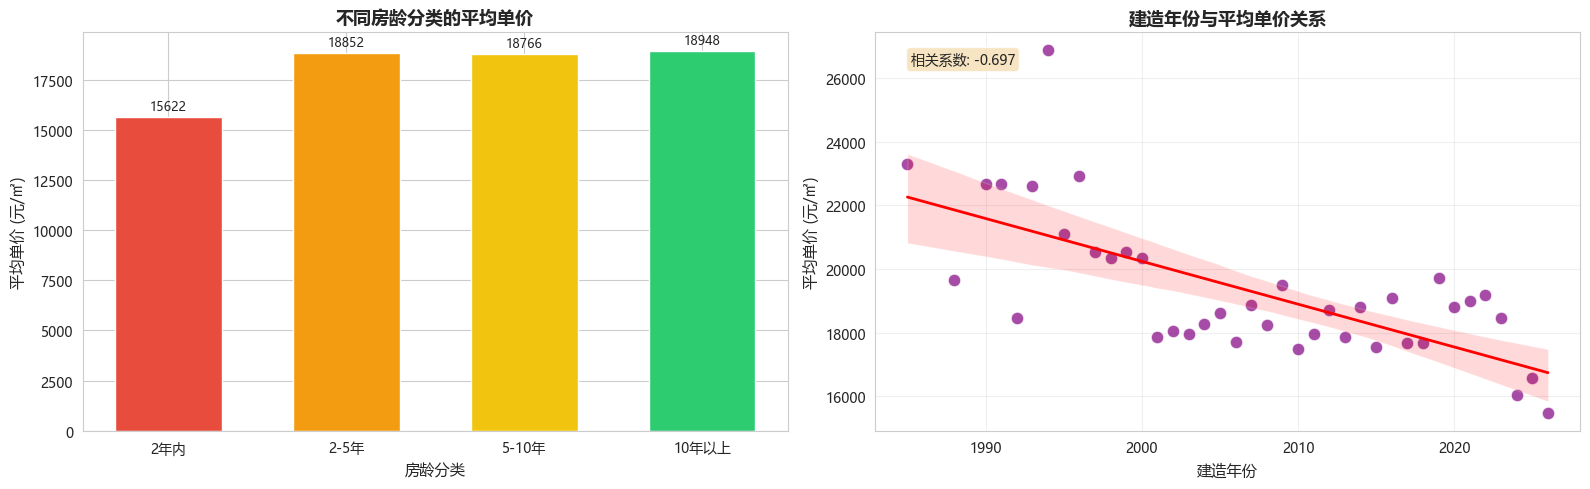

In [156]:
print("房龄列所有分类：", df_clean['房龄'].unique())
print("\n每个分类的房源数量：\n", df_clean['房龄'].value_counts())
# 图5: 房龄与均价的关系
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))  # 加宽画布，给左图留足空间

# ========== 左图：房龄分类柱状图 ==========
age_order = ['2年内', '2-5年', '5-10年', '10年以上']
# 按指定顺序重排，同时过滤空值避免无效柱
age_price = df_clean.groupby('房龄')['均价_清洗后(元/㎡)'].mean().reindex(age_order).dropna()

# 改用区分度高的渐变色，避免同色系糊成一团
bar_colors = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71', '#3498db']
bars = ax1.bar(age_price.index, age_price.values, color=bar_colors, width=0.6)

ax1.set_title('不同房龄分类的平均单价', fontsize=13, fontweight='bold')
ax1.set_xlabel('房龄分类', fontsize=11)
ax1.set_ylabel('平均单价 (元/㎡)', fontsize=11)
# 标签水平显示，避免旋转截断
ax1.tick_params(axis='x', labelsize=10)

# 柱顶添加数值标签，自适应位置
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 200,
             f'{height:.0f}', ha='center', va='bottom', fontsize=9)

# ========== 右图：建造年份散点图 ==========
year_price = df_clean.groupby('建造年份')['均价_清洗后(元/㎡)'].mean().reset_index()

sns.scatterplot(data=year_price, x='建造年份', y='均价_清洗后(元/㎡)',
                s=80, color='purple', alpha=0.7, ax=ax2)
sns.regplot(data=year_price, x='建造年份', y='均价_清洗后(元/㎡)',
            scatter=False, color='red', line_kws={'lw':2}, ax=ax2)

ax2.set_title('建造年份与平均单价关系', fontsize=13, fontweight='bold')
ax2.set_xlabel('建造年份', fontsize=11)
ax2.set_ylabel('平均单价 (元/㎡)', fontsize=11)
ax2.grid(True, alpha=0.3)

# 相关系数标注优化
year_corr = year_price['建造年份'].corr(year_price['均价_清洗后(元/㎡)'])
ax2.text(0.05, 0.95, f'相关系数: {year_corr:.3f}', 
         transform=ax2.transAxes, fontsize=10, 
         va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

**图表解读：**
福州二手房价格呈现 “老房单价更高” 的特征，建造年份与均价整体呈强负相关（相关系数 - 0.697）。2 年内次新房平均单价最低，房龄超过 2 年后均价进入高位平台期，10 年以上房源单价最高。
该现象主要受地段与配套因素驱动：高单价老房多集中在核心主城区，叠加优质学区溢价，地段价值的影响超过了房龄折旧；而近年新建房源大量分布在外围板块，拉低了次新房的整体均价。

### 7.6 户型分布与价格对比

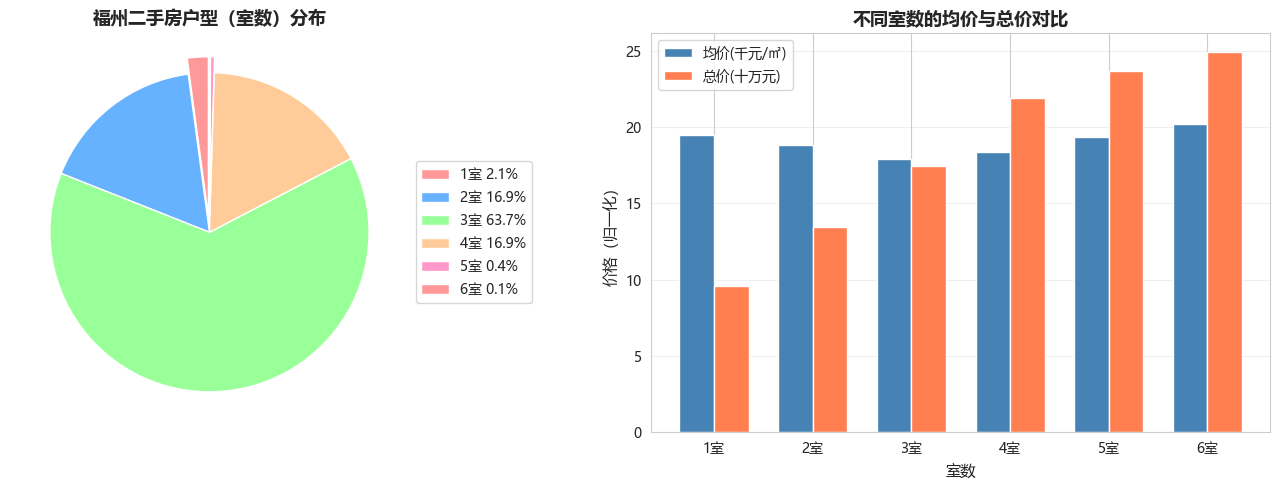

In [157]:
# 图6：户型分布与价格对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 室数分布饼图
room_counts = df_clean['室数'].value_counts().sort_index()
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
wedges, texts = ax1.pie(room_counts.values, labels=None, colors=colors, startangle=90, explode=explode)
# 右侧新增图例，同时显示户型+占比
label_list = [f'{int(x)}室 {room_counts[x]/room_counts.sum():.1%}' for x in room_counts.index]
ax1.legend(wedges, label_list, loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
ax1.set_title('福州二手房户型（室数）分布', fontsize=13, fontweight='bold')
# 不同室数的均价和总价对比
room_data = df_clean.groupby('室数').agg({
    '均价_清洗后(元/㎡)': 'mean',
    '总价_清洗后(万)': 'mean'
}).reset_index()

x = np.arange(len(room_data))
width = 0.35

bars1 = ax2.bar(x - width/2, room_data['均价_清洗后(元/㎡)']/1000, width, label='均价(千元/㎡)', color='steelblue')
bars2 = ax2.bar(x + width/2, room_data['总价_清洗后(万)']/10, width, label='总价(十万元)', color='coral')

ax2.set_xlabel('室数', fontsize=11)
ax2.set_ylabel('价格（归一化）', fontsize=11)
ax2.set_title('不同室数的均价与总价对比', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{int(x)}室' for x in room_data['室数']])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**图表解读：**
3室户型是福州二手房市场的绝对主力，占比超过一半，说明刚需和改善型需求是市场主流。2室户型次之，主要面向首次置业的刚需群体。从价格来看，随着室数增加，总价显著上升，但单价的变化相对较小，说明大户型主要是通过面积增加来推高总价，单价溢价并不明显。

## 8. 主要结论

通过对福州二手房数据的全面分析，我们得出以下主要结论：

### 8.1 市场整体特征
1. **价格水平**：福州二手房平均单价约2万元/㎡，平均总价约200万元，整体市场处于中等偏上水平
2. **供应结构**：3室2厅户型占比最高，面积集中在80-120㎡，以刚需和改善型房源为主
3. **区域分布**：仓山区房源供应量最大，市场最为活跃

### 8.2 区域差异显著
1. **鼓楼区房价最高**：作为传统核心城区，鼓楼区均价领先，体现了学区、配套和区位优势
2. **台江、晋安居中**：两个城区房价水平相近，处于全市中间位置
3. **仓山相对亲民**：仓山区整体房价相对较低，但内部差异较大，既有低价刚需盘也有高端项目

### 8.3 房价影响因素
1. **房龄因素**：房龄与房价呈明显正相关，老房价格显著高于新房，2年内房龄的房源均价最低
2. **面积因素**：面积与总价高度正相关，是影响总价的最主要因素
3. **朝向因素**：南北通透房源占比最高且均价相对较高，体现了市场对良好朝向的偏好
4. **楼层因素**：不同楼层位置的价格差异不大，说明楼层对福州二手房价格影响相对有限

### 8.4 市场建议
1. **刚需购房者**：可重点关注仓山区和晋安区的2-3室房源，性价比相对较高
2. **改善型需求**：鼓楼区和台江区的次新房是较好选择，配套成熟且居住品质较高
3. **投资角度**：次新房和地铁沿线房源保值增值能力相对较强

### 8.5 数据局限性说明
1. 本数据仅来源于单一平台，可能无法完全代表整个福州二手房市场
2. 数据主要集中在几个主要城区，其他区域数据较少
3. 挂牌价与实际成交价可能存在差异
4. 部分字段存在缺失和异常值，已做相应处理但可能对结果有一定影响

---

**报告完成时间**：2026年6月24日  
**数据来源**：安居客福州二手房数据  
**分析工具**：Python + Pandas + Matplotlib + Seaborn